**General analysis on experiments of different `c_k`: Extended output**
- Author: Muxin Hu (muxin.hu@mpimet.mpg.de)
- Date created: 17/03/2026
- Lastest modified: 17/03/2026

**Paths**
- the pyic package is downloaded and installed in the directory: `/home/m/m301254/Download/pyicon`

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pyicon as pyic
import cartopy.crs as ccrs
import sys
import cartopy.feature as cfeature
from matplotlib import cm
import cftime

# import custom functions
import funcs_crop_region as funcs_crop_region

# Pre-required import (i.e., compute node) for Dask
import intake
from distributed import Client, LocalCluster

----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.


ERROR 1: PROJ: proj_create_from_database: Open of /home/m/m301254/.conda/envs/env02_waves/share/proj failed


----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


In [2]:
cluster = LocalCluster(
    n_workers=64, 
    threads_per_worker=2,
    local_directory="/scratch/m/m301254/dask_tmp/"
)
client = Client(cluster)
client.restart()   
client

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (1.21s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)
/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (1.22s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)
/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (1.23s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 64
Total threads: 128,Total memory: 251.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38291,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40865,Total threads: 2
Dashboard: http://127.0.0.1:38665/status,Memory: 3.93 GiB
Nanny: tcp://127.0.0.1:35327,


# Data, tgrid, mask path

In [3]:
# data, grid paths
run_def='mux0003_b5b7'
run_ck3='mux0003_b5b7_c_k-03'

gname_oce = 'r2b7_oce_r0005'
gname_atm = 'r2b5_atm_r0030'
lev_oce = 'L72'

# data paths
path_data = {}
path_data["def"] = (f'/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/{run_def}/outdata/')
path_data["ck3"] = (f'/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/{run_ck3}/outdata/')


# grid paths
path_grid_oce = f'/home/m/m301254/pyicon_data/grids/{gname_oce}/'
path_grid_atm = f'/home/m/m301254/pyicon_data/grids/{gname_atm}/'

# ckdtree paths
fpath_tgrid = {}
fpath_ckdtree = {}
# specify the file paths for different components
fpath_tgrid['atm'] = (f'{path_grid_atm}{gname_atm}_tgrid.nc')
fpath_tgrid['oce'] = (f'{path_grid_oce}{gname_oce}_tgrid.nc')

fpath_ckdtree['atm'] = (f'{path_grid_atm}ckdtree/rectgrids/r2b5_atm_r0030_res0.30_180W-180E_90S-90N.nc')
fpath_ckdtree['oce'] = (f'{path_grid_oce}ckdtree/rectgrids/r2b7_oce_r0005_res0.30_180W-180E_90S-90N.nc')

# read data
ds_tg_atm = xr.open_dataset(fpath_tgrid['atm'])
ds_tg_oce = xr.open_dataset(fpath_tgrid['oce'])

# fx file for ocean grid
ds_fx_oce = xr.open_dataset(f'{path_grid_oce}{gname_oce}_{lev_oce}_fx.nc')

In [4]:
ds_tg_atm

<xarray.Dataset> Size: 52MB
Dimensions:                        (cell: 81920, nv: 3, vertex: 40962, ne: 6,
                                    edge: 122880, no: 4, nc: 2,
                                    vert_delaunay: 3, cell_delaunay: 163836)
Coordinates:
    clon                           (cell) float64 655kB ...
    clat                           (cell) float64 655kB ...
    vlon                           (vertex) float64 328kB ...
    vlat                           (vertex) float64 328kB ...
    elon                           (edge) float64 983kB ...
    elat                           (edge) float64 983kB ...
Dimensions without coordinates: cell, nv, vertex, ne, edge, no, nc,
                                vert_delaunay, cell_delaunay
Data variables: (12/43)
    clon_vertices                  (cell, nv) float64 2MB ...
    clat_vertices                  (cell, nv) float64 2MB ...
    vlon_vertices                  (vertex, ne) float64 2MB ...
    vlat_vertices                  (vertex, ne) float64 2MB ...
    elon_vertices                  (edge, no) float64 4MB ...
    elat_vertices                  (edge, no) float64 4MB ...
    ...                             ...
    neighbor_cell_index            (nv, cell) int32 983kB ...
    edge_index                     (edge) int32 492kB ...
    vertex_index                   (vertex) int32 164kB ...
    edge_orientation               (ne, vertex) int32 983kB ...
    edge_system_orientation        (edge) int32 492kB ...
    cc_delaunay                    (vert_delaunay, cell_delaunay) int32 2MB ...
Attributes: (12/21)
    title:                ICON grid description
    history:              /panfs/e/vol2/gzaengl/icon-dev/build/x86_64-unknown...
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    source:               icon-dev
    uuidOfHGrid:          a668eac0-fe2e-11e4-9a47-e3e5371a87a7
    number_of_grid_used:  30
    ...                   ...
    inverse_flattening:   0.0
    grid_level:           5
    grid_root:            2
    grid_ID:              1
    parent_grid_ID:       0
    max_childdom:         1

In [16]:
ds_tg_oce

<xarray.Dataset> Size: 887MB
Dimensions:                         (cell: 935760, nv: 3, vertex: 475655,
                                     ne: 6, edge: 1411768, no: 4, nc: 2,
                                     max_stored_decompositions: 4, two_grf: 2,
                                     cell_grf: 14, max_chdom: 1, edge_grf: 24,
                                     vert_grf: 13)
Coordinates:
    clon                            (cell) float64 7MB 1.274 1.282 ... 1.333
    clat                            (cell) float64 7MB ...
    vlon                            (vertex) float64 4MB 1.282 1.266 ... 1.337
    vlat                            (vertex) float64 4MB ...
    elon                            (edge) float64 11MB 1.278 1.274 ... 1.333
    elat                            (edge) float64 11MB ...
Dimensions without coordinates: cell, nv, vertex, ne, edge, no, nc,
                                max_stored_decompositions, two_grf, cell_grf,
                                max_chdom, edge_grf, vert_grf
Data variables: (12/91)
    clon_vertices                   (cell, nv) float64 22MB ...
    clat_vertices                   (cell, nv) float64 22MB ...
    vlon_vertices                   (vertex, ne) float64 23MB ...
    vlat_vertices                   (vertex, ne) float64 23MB ...
    elon_vertices                   (edge, no) float64 45MB ...
    elat_vertices                   (edge, no) float64 45MB ...
    ...                              ...
    edge_dual_normal_cartesian_x    (edge) float64 11MB ...
    edge_dual_normal_cartesian_y    (edge) float64 11MB ...
    edge_dual_normal_cartesian_z    (edge) float64 11MB ...
    cell_circumcenter_cartesian_x   (cell) float64 7MB ...
    cell_circumcenter_cartesian_y   (cell) float64 7MB ...
    cell_circumcenter_cartesian_z   (cell) float64 7MB ...
Attributes: (12/34)
    title:                    ICON grid description
    institution:              Max Planck Institute for Meteorology/Deutscher ...
    source:                   Unknown
    revision:                 Unknown
    history:                  /work/mh0287/users/leonidas/icon/GridGenerator_...
    date:                     20191211 at 195212
    ...                       ...
    mean_cell_area:           389176284.94852674
    mean_dual_cell_area:      778350194.560874
    domain_length:            40031612.44147649
    domain_height:            40031612.44147649
    sphere_radius:            6371229.0
    domain_cartesian_center:  [0. 0. 0.]

In [4]:
# mask: pc_all in atm and oce differently
fpath_mask = f"/work/mh0033/m301254/proj_surfwave/masks"

mask_atm = xr.open_dataset(f"{fpath_mask}/pc_all_mask_atm_r2b5.nc")
mask_atm_plot = xr.open_dataset(f"{fpath_mask}/pc_masks_atm_full-dim.nc")
mask_oce = xr.open_dataset(f"{fpath_mask}/secs_to_mask/pc_all_sections_masks_oce_r2b7.nc")

In [5]:
# crop the tgrid files to the region
ds_IcD_oce, crop_tg_oce, contained_cells_oce = funcs_crop_region.crop_tgrid_to_region(ds_tg_oce, mask_oce)

find edges
cut coordinates
reindex


In [6]:
np.all(crop_tg_oce.cell.values == mask_oce.contained_cells.values)

np.True_

# Atmosphere 2D,3D differences
- check the differences in:
    - **regional mean 10 m wind speed**: annual-mean & monthly-mean climatology
    - **MSLP**: annual-mean, monthly mean climatology
    - **regional mean wind profiles** at the lowest atmospehre: annual-mean & monthly-mean climatology
    - **cloud cover differences**

## 10 m wind speed

In [7]:
sp10_def = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_2d_*")["sp_10m"].isel(height=0)
sp10_ck3 = xr.open_mfdataset(f"{path_data['ck3']}{run_ck3}_atm_2d_*")["sp_10m"].isel(height=0)

/tmp/ipykernel_587969/3283141258.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  sp10_def = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_2d_*")["sp_10m"].isel(height=0)
/tmp/ipykernel_587969/3283141258.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  sp10_def = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_2d_*")["sp_10m"].isel(height=0)
/tmp/ipykernel_587969/3283141258.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=

In [8]:
# monthly climatology
sp10_def_monthly = sp10_def.groupby("time.month").mean("time")
sp10_ck3_monthly = sp10_ck3.groupby("time.month").mean("time")

# calculate the selected regional mean 
sp10_def_monthly_reg = funcs_crop_region.regional_area_mean_atm(sp10_def_monthly, ds_tg_atm, mask_atm)
sp10_ck3_monthly_reg = funcs_crop_region.regional_area_mean_atm(sp10_ck3_monthly, ds_tg_atm, mask_atm)

In [13]:
# climatology of annual mean
sp10_def_clim = sp10_def.mean(dim="time")
sp10_ck3_clim = sp10_ck3.mean(dim="time")

# selected regional mean
sp10_def_clim_reg = funcs_crop_region.regional_area_mean_atm(sp10_def_clim, ds_tg_atm, mask_atm)
sp10_ck3_clim_reg = funcs_crop_region.regional_area_mean_atm(sp10_ck3_clim, ds_tg_atm, mask_atm)

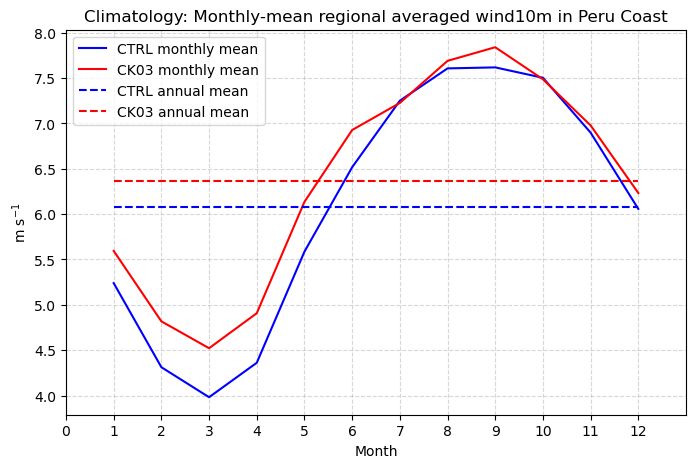

In [21]:
plt.figure(figsize=(8,5))
plt.plot(sp10_def_monthly_reg.month, sp10_def_monthly_reg, c="b", label="CTRL monthly mean")
plt.plot(sp10_ck3_monthly_reg.month, sp10_ck3_monthly_reg, c="r", label="CK03 monthly mean")
plt.hlines(sp10_def_clim_reg, 1, 12, colors='b', linestyles='dashed', label="CTRL annual mean")
plt.hlines(sp10_ck3_clim_reg, 1, 12, colors='r', linestyles='dashed', label="CK03 annual mean")
plt.xlabel("Month")
plt.xlim(0,13)
plt.xticks(range(0,13))
plt.ylabel("m s$^{-1}$")
plt.legend()
plt.grid(True, alpha=0.5, linestyle='--')
plt.title("Climatology: Monthly-mean regional averaged wind10m in Peru Coast")

save_path = "/home/m/m301254/project_surfwaves/figs/mux0003_b5b7/pc_all/clim_wind10m_monthly_ave_pc-all.png"
plt.savefig(save_path, dpi=100)
plt.show()

In [7]:
# large seasonal difference in wind10m
months_aso = [8,9,10]
months_fma = [2,3,4]

## MSLP: CTRL clima & (CK03-CTRL)

In [6]:
mslp_def = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_2d_*")["pres_msl"]
mslp_ck3 = xr.open_mfdataset(f"{path_data['ck3']}{run_ck3}_atm_2d_*")["pres_msl"]

/tmp/ipykernel_198054/1349272161.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  mslp_def = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_2d_*")["pres_msl"]
/tmp/ipykernel_198054/1349272161.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  mslp_def = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_2d_*")["pres_msl"]
/tmp/ipykernel_198054/1349272161.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  mslp_def = xr.ope

In [9]:
# select month
mslp_def_aso = mslp_def.sel(time=mslp_def.time.dt.month.isin(months_aso))
mslp_ck3_aso = mslp_ck3.sel(time=mslp_ck3.time.dt.month.isin(months_aso))

mslp_def_fma = mslp_def.sel(time=mslp_def.time.dt.month.isin(months_fma))
mslp_ck3_fma = mslp_ck3.sel(time=mslp_ck3.time.dt.month.isin(months_fma))

In [10]:
# calculate: (1) Annual climatology of mslp; (2) Seasonal climatology of mslp in ASO and FMA
mslp_def_clim = mslp_def.mean(dim="time").compute()/100  # convert to hPa
mslp_ck3_clim = mslp_ck3.mean(dim="time").compute()/100

mslp_def_aso_clim = mslp_def_aso.mean(dim="time").compute()/100
mslp_ck3_aso_clim = mslp_ck3_aso.mean(dim="time").compute()/100

mslp_def_fma_clim = mslp_def_fma.mean(dim="time").compute()/100
mslp_ck3_fma_clim = mslp_ck3_fma.mean(dim="time").compute()/100

In [11]:
# calculate: climatological difference between CTRL, CK03
mslp_clim_diff = mslp_ck3_clim - mslp_def_clim
mslp_aso_clim_diff = mslp_ck3_aso_clim - mslp_def_aso_clim
mslp_fma_clim_diff = mslp_ck3_fma_clim - mslp_def_fma_clim

Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


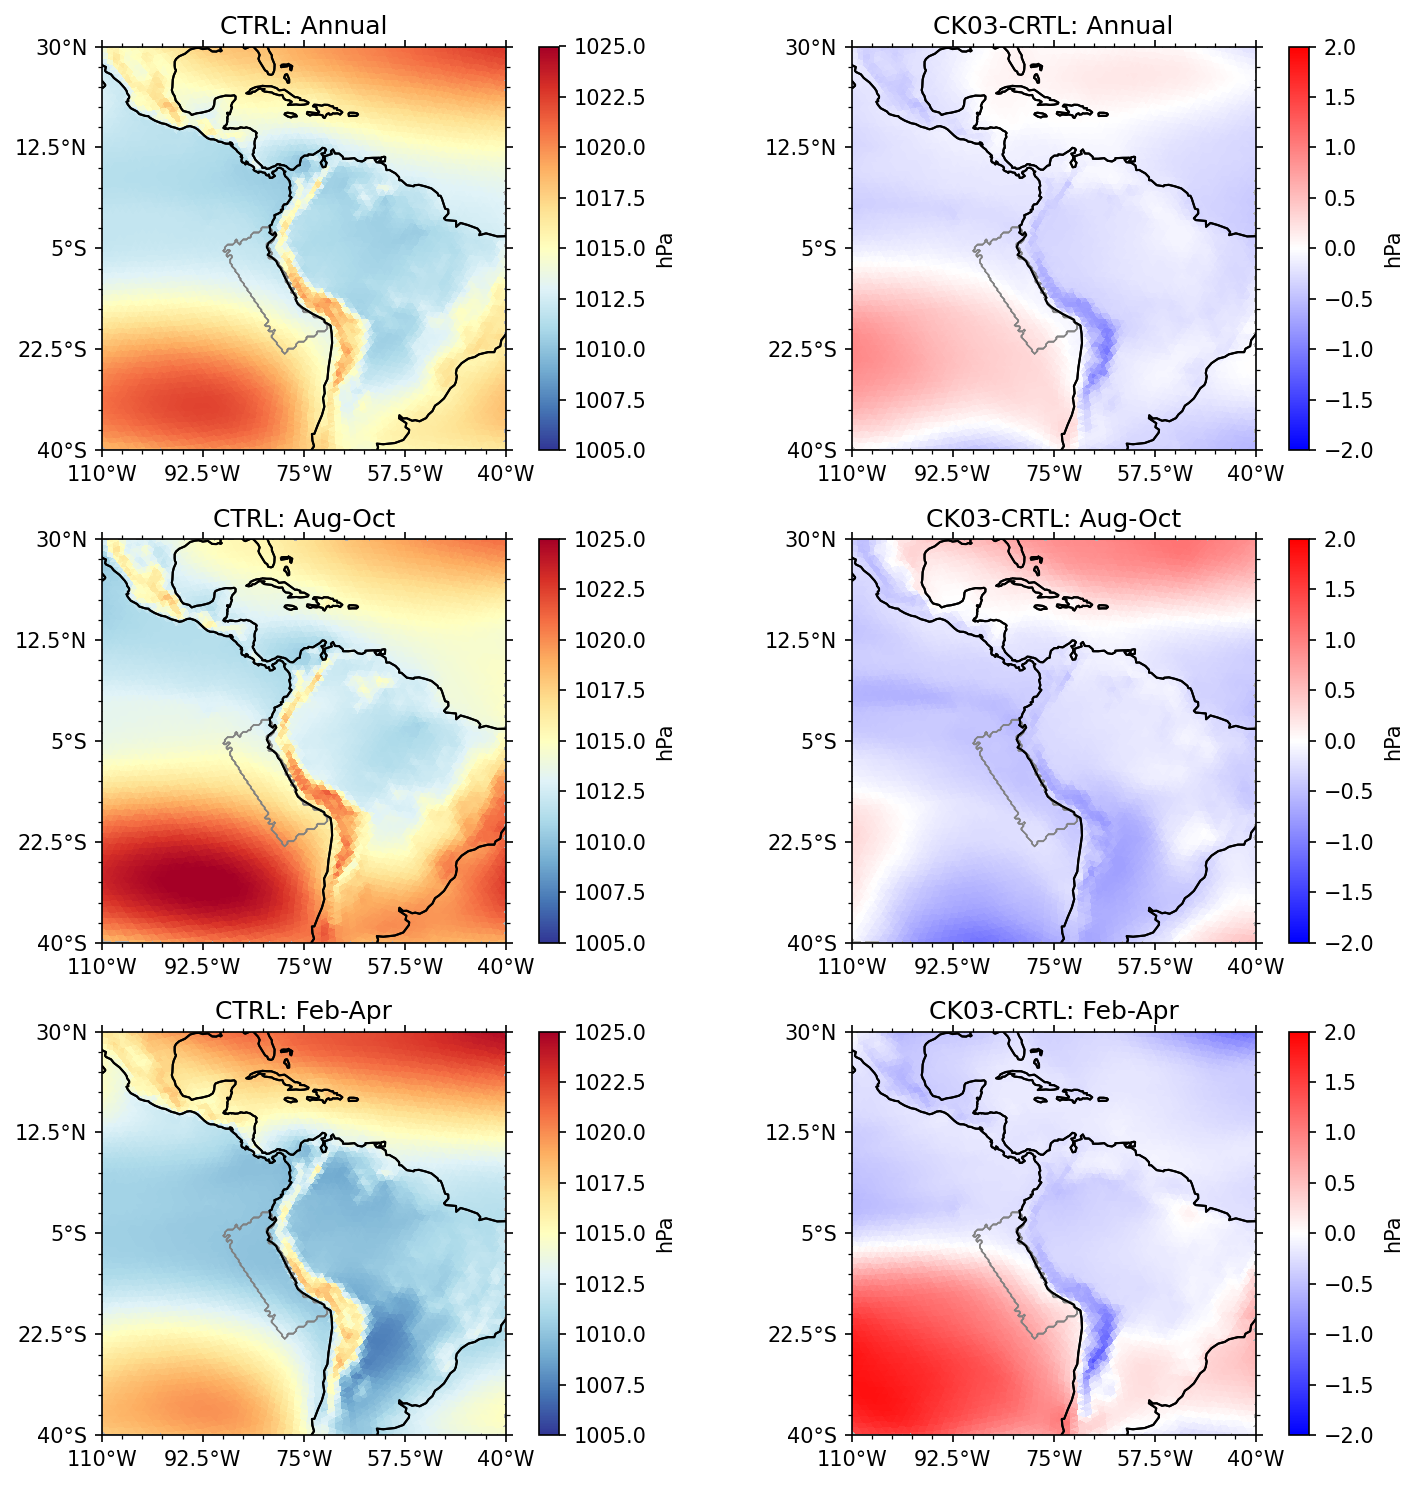

In [32]:
# plot
fields = [
    ("CTRL: Annual", mslp_def_clim, "clima"),
    ("CK03-CRTL: Annual", mslp_clim_diff, "diff"),
    ("CTRL: Aug-Oct", mslp_def_aso_clim, "clima"),
    ("CK03-CRTL: Aug-Oct", mslp_aso_clim_diff, "diff"),
    ("CTRL: Feb-Apr", mslp_def_fma_clim, "clima"),
    ("CK03-CRTL: Feb-Apr", mslp_fma_clim_diff, "diff"),
]

fig, axes = plt.subplots(3, 2, figsize=(10,10),
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            # constrained_layout=True,
                            dpi=150,)
axes = axes.flatten()

clim_clima = [1005, 1025]   # climatology
clim_diff = [-2, 2]       # ASO − FMA

for ax, (title, field, kind) in zip(axes, fields):
    clim = clim_diff if kind == "diff" else clim_clima
    cmap = "auto" if kind == "clima" else cm.bwr
    ax, ct = field.pyic.plot(
        ax=ax, cax=0,
        fpath_tgrid=fpath_tgrid["atm"], 
        fpath_ckdtree=fpath_ckdtree["atm"],
        title_right="",
        plot_method='tgrid',
        land_facecolor="none",
        lon_reg=[-110, -40],
        lat_reg=[-40, 30],
        cmap=cmap,
        # use_pcol_or_contf=True, 
        # conts="auto",
        clim=clim,
    )
    fig.colorbar(ct[0], ax=ax, orientation='vertical', label='hPa', pad=0.05)
 
    ax, ct = (mask_atm_plot["pc_all"] + 1).pyic.plot(
        ax=ax, cax=0,
        fpath_tgrid=fpath_tgrid['atm'],
        fpath_ckdtree=fpath_ckdtree['atm'],
        lon_reg=[-110, -40],
        lat_reg=[-40, 30],
        land_facecolor="none",
        use_pcol_or_contf=False,
        conts=1.0,
        contcolor='grey',
    )
    for line in ct:
        line.set_linewidths(0.2)
        # line.set_linestyle('dashed')

    ax.set_title(f"{title}")
    # ax.set_xticks([])
    # ax.set_yticks([])

fig.tight_layout()
save_path = "/home/m/m301254/project_surfwaves/figs/mux0003_b5b7/pc_all/clim_mslp_clima_vs_diff_pc-all.png"
plt.savefig(save_path, dpi=100)
plt.show()

## MSLP gradient

### Calculate gradient in native grid --> impossible

In [14]:
# use the pyicon to calculate the gradient of mslp.
# however, need to specify the new function: pyic.convert_tgrid_data

import warnings
from itertools import product

def convert_tgrid_data_new(ds_tg_in, check_previous_conversion=True, set_dim_order=None, old_dim_behaviour=None):
    ds_tg = ds_tg_in.copy(deep=True)

    if old_dim_behaviour is None:
        warnings.warn(
            "The default behaviour for convert_tgrid has changed. "
            "Dimension labels 'nc', 'ne', 'nv' are now corrected.",
            DeprecationWarning,
        )

    if check_previous_conversion and "converted_tgrid" in ds_tg.attrs:
        raise ValueError(
            "Dataset already converted. Set check_previous_conversion=False to override."
        )

    ds_IcD = xr.Dataset()

    # -------------------------
    # constants
    # -------------------------
    ds_IcD["grid_sphere_radius"] = 6.371229e6
    ds_IcD["grav"] = 9.80665
    ds_IcD["earth_angular_velocity"] = 7.29212e-05
    ds_IcD["rho0"] = 1025.022
    ds_IcD["rhoi"] = 917.0
    ds_IcD["rhos"] = 300.0
    ds_IcD["sal_ref"] = 35.0
    ds_IcD["sal_ice"] = 5.0
    rcpl = 3.1733
    cpd = 1004.64
    ds_IcD["cp"] = (rcpl + 1.0) * cpd
    ds_IcD["tref"] = 273.15
    ds_IcD["tmelt"] = 273.15
    ds_IcD["tfreeze"] = -1.9
    ds_IcD["alf"] = 2.8345e6 - 2.5008e6

    # -------------------------
    # distances and areas
    # -------------------------
    ds_IcD["cell_area"] = ds_tg["cell_area"]
    ds_IcD["cell_area_p"] = ds_tg["cell_area_p"]
    ds_IcD["dual_area"] = ds_tg["dual_area"]
    ds_IcD["edge_length"] = ds_tg["edge_length"]
    ds_IcD["dual_edge_length"] = ds_tg["dual_edge_length"]
    ds_IcD["edge_cell_distance"] = ds_tg["edge_cell_distance"].transpose()

    # -------------------------
    # neighbor information
    # -------------------------
    ds_IcD["vertex_of_cell"] = ds_tg["vertex_of_cell"].transpose() - 1
    ds_IcD["edge_of_cell"] = ds_tg["edge_of_cell"].transpose() - 1
    ds_IcD["vertices_of_vertex"] = ds_tg["vertices_of_vertex"].transpose() - 1
    ds_IcD["edges_of_vertex"] = ds_tg["edges_of_vertex"].transpose() - 1
    ds_IcD["edge_vertices"] = ds_tg["edge_vertices"].transpose() - 1
    ds_IcD["adjacent_cell_of_edge"] = ds_tg["adjacent_cell_of_edge"].transpose() - 1
    ds_IcD["cells_of_vertex"] = ds_tg["cells_of_vertex"].transpose() - 1
    ds_IcD["adjacent_cell_of_cell"] = ds_tg["neighbor_cell_index"].transpose() - 1

    # -------------------------
    # orientation
    # -------------------------
    ds_IcD["orientation_of_normal"] = ds_tg["orientation_of_normal"].transpose()
    ds_IcD["edge_orientation"] = ds_tg["edge_orientation"].transpose()
    ds_IcD["tangent_orientation"] = ds_tg["edge_system_orientation"].transpose()

    # -------------------------
    # masks (missing in your dataset)
    # -------------------------
    try:
        ds_IcD["cell_sea_land_mask"] = ds_tg["cell_sea_land_mask"]
    except KeyError:
        warnings.warn("cell_sea_land_mask not found in grid file.", UserWarning)

    try:
        ds_IcD["edge_sea_land_mask"] = ds_tg["edge_sea_land_mask"]
    except KeyError:
        warnings.warn("edge_sea_land_mask not found in grid file.", UserWarning)

    # -------------------------
    # cartesian coordinates (all missing in your dataset)
    # -------------------------
    cartesian_vars = [
        ("cell_cart_vec", ["cell_circumcenter_cartesian_x",
                           "cell_circumcenter_cartesian_y",
                           "cell_circumcenter_cartesian_z"]),
        ("vert_cart_vec", ["cartesian_x_vertices",
                           "cartesian_y_vertices",
                           "cartesian_z_vertices"]),
        ("edge_cart_vec", ["edge_middle_cartesian_x",
                           "edge_middle_cartesian_y",
                           "edge_middle_cartesian_z"]),
        ("dual_edge_cart_vec", ["edge_dual_middle_cartesian_x",
                                "edge_dual_middle_cartesian_y",
                                "edge_dual_middle_cartesian_z"]),
        ("edge_prim_norm", ["edge_primal_normal_cartesian_x",
                            "edge_primal_normal_cartesian_y",
                            "edge_primal_normal_cartesian_z"]),
    ]

    for dst_name, src_vars in cartesian_vars:
        try:
            ds_IcD[dst_name] = xr.concat([ds_tg[v] for v in src_vars], dim="cart").transpose()
        except KeyError:
            warnings.warn(f"Cartesian coordinates for {dst_name} not found.", UserWarning)

    # -------------------------
    # latitude / longitude
    # -------------------------
    for point, dim in product("ecv", ("lat", "lon")):
        coord = point + dim
        try:
            ds_IcD[coord] = ds_tg[coord] * 180.0 / np.pi
            ds_IcD[coord].attrs["units"] = "degrees"
        except KeyError:
            warnings.warn(f"{coord} not found in grid file.", UserWarning)

    # -------------------------
    # coriolis
    # -------------------------
    try:
        ds_IcD["fc"] = 2.0 * ds_IcD.earth_angular_velocity * np.sin(ds_IcD.clat * np.pi / 180.0)
    except KeyError:
        warnings.warn("clat missing; cannot compute fc.", UserWarning)

    try:
        ds_IcD["fe"] = 2.0 * ds_IcD.earth_angular_velocity * np.sin(ds_IcD.elat * np.pi / 180.0)
    except KeyError:
        warnings.warn("elat missing; cannot compute fe.", UserWarning)

    try:
        ds_IcD["fv"] = 2.0 * ds_IcD.earth_angular_velocity * np.sin(ds_IcD.vlat * np.pi / 180.0)
    except KeyError:
        warnings.warn("vlat missing; cannot compute fv.", UserWarning)

    # -------------------------
    # rename and dimension order
    # -------------------------
    try:
        ds_IcD = ds_IcD.rename({"ncells": "cell"})
    except ValueError:
        pass

    ds_IcD.attrs["converted_tgrid"] = True
    ds_tg.attrs["converted_tgrid"] = True

    if set_dim_order is None:
        standard_order = ["cell", "vertex", "edge", "nc", "nv", "ne", "cart"]
        ds_IcD = ds_IcD.transpose(*standard_order, missing_dims="ignore")
    elif set_dim_order:
        ds_IcD = ds_IcD.transpose(*set_dim_order, missing_dims="ignore")

    return ds_IcD

In [15]:
ds_IcD_atm = convert_tgrid_data_new(ds_tg_atm)

/tmp/ipykernel_198054/1035385556.py:11: DeprecationWarning: The default behaviour for convert_tgrid has changed. Dimension labels 'nc', 'ne', 'nv' are now corrected.
  warnings.warn(
/tmp/ipykernel_198054/1035385556.py:78: UserWarning: cell_sea_land_mask not found in grid file.
  warnings.warn("cell_sea_land_mask not found in grid file.", UserWarning)
/tmp/ipykernel_198054/1035385556.py:83: UserWarning: edge_sea_land_mask not found in grid file.
  warnings.warn("edge_sea_land_mask not found in grid file.", UserWarning)
/tmp/ipykernel_198054/1035385556.py:110: UserWarning: Cartesian coordinates for cell_cart_vec not found.
  warnings.warn(f"Cartesian coordinates for {dst_name} not found.", UserWarning)
/tmp/ipykernel_198054/1035385556.py:110: UserWarning: Cartesian coordinates for vert_cart_vec not found.
  warnings.warn(f"Cartesian coordinates for {dst_name} not found.", UserWarning)
/tmp/ipykernel_198054/1035385556.py:110: UserWarning: Cartesian coordinates for edge_cart_vec not found

In [ ]:
# calculate the gradient coefficient (1/dx) using pyic.xr_calc_grad_coeff(ds_IcD_atm)
grad_coeff = pyic.xr_calc_grad_coeff(ds_IcD_atm)

In [ ]:
# formula: mslp gradient = (mslp at adjacent cell 1 - mslp at adjacent cell 0) * grad_coeff
# shape: (time, edges) -> vector on edges
gradh_mslp_def = (mslp_def[:,ds_IcD_atm.adjacent_cell_of_edge[:,1]]-mslp_def[:,ds_IcD_atm.adjacent_cell_of_edge[:,0]])*grad_coeff

gradh_mslp_ck3 = (mslp_ck3[:,ds_IcD_atm.adjacent_cell_of_edge[:,1]]-mslp_ck3[:,ds_IcD_atm.adjacent_cell_of_edge[:,0]])*grad_coeff

In [28]:
# calculate the edge2cell coefficient
edge2cell_coeff = pyic.xr_calc_edge2cell_coeff_cc(ds_IcD_atm)

# map the gradient on edge space back to cell space
# p_gradh_mslp_def = edge2cell_coeff * gradh_mslp_def.isel(edge=ds_IcD_atm.edge_of_cell)
# p_gradh_mslp_ck3 = edge2cell_coeff * gradh_mslp_ck3.isel(edge=ds_IcD_atm.edge_of_cell)

AttributeError: 'Dataset' object has no attribute 'edge_cart_vec'

It seems that the DWD atmospheric grid cannot use the pyicon library to calculate.
- key missing parameters:
    - "cell_circumcenter_cartesian_x", "cell_circumcenter_cartesian_y", --> affect "cell_cart_vec"
    - "cartesian_x_vertices", "cartesian_y_vertices", "cartesian_z_vertices" --> affect "vert_cart_vec"
    - "edge_middle_cartesian_x", "edge_middle_cartesian_y", "edge_middle_cartesian_z", --> affect "edge_cart_vec" --> which is needed when using `pyic.xr_calc_edge2cell_coeff_cc`

### Calculate gradient after interpolation

## Monthly mean wind profile at lowest atmosphere

In [20]:
# pressure level speculation
pres_test  = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_3d_*")["pres"].isel(time=0)

/tmp/ipykernel_112726/1785137723.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  pres_test  = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_3d_*")["pres"].isel(time=0)
/tmp/ipykernel_112726/1785137723.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  pres_test  = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_3d_*")["pres"].isel(time=0)
/tmp/ipykernel_112726/1785137723.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True

In [27]:
print(pres_test.isel(height=0).values.min())
print(pres_test.isel(height=129).values.max())

1.0211669
103034.625


Deriving triangulation object, this can take a while...
Done deriving triangulation object.


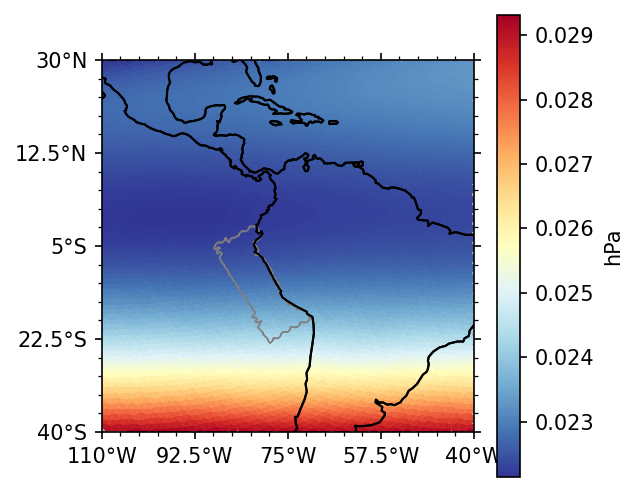

In [24]:
pres_test_h = pres_test.isel(height=0) / 100  # convert to hPa

fig, ax = plt.subplots(figsize=(4,4),
                       subplot_kw={'projection': ccrs.PlateCarree()},
                       dpi=150,)
ax, ct = pres_test_h.pyic.plot(
        ax=ax, cax=0,
        fpath_tgrid=fpath_tgrid["atm"], 
        fpath_ckdtree=fpath_ckdtree["atm"],
        title_right="",
        plot_method='tgrid',
        land_facecolor="none",
        lon_reg=[-110, -40],
        lat_reg=[-40, 30],
        cmap="RdYlBu_r",
        # use_pcol_or_contf=True, 
        # conts="auto",
)
fig.colorbar(ct[0], ax=ax, orientation='vertical', label='hPa', pad=0.05)

ax, ct = (mask_atm_plot["pc_all"] + 1).pyic.plot(
        ax=ax, cax=0,
        fpath_tgrid=fpath_tgrid['atm'],
        fpath_ckdtree=fpath_ckdtree['atm'],
        lon_reg=[-110, -40],
        lat_reg=[-40, 30],
        land_facecolor="none",
        use_pcol_or_contf=False,
        conts=1.0,
        contcolor='grey',
    )
for line in ct:
    line.set_linewidths(0.2)
    # line.set_linestyle('dashed')

In [8]:
# read the zonal and meridional wind components
u_def  = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_3d_*")["u"].isel(height=slice(0,10))
v_def  = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_3d_*")["v"].isel(height=slice(0,10))
u_ck3  = xr.open_mfdataset(f"{path_data['ck3']}{run_ck3}_atm_3d_*")["u"].isel(height=slice(0,10))
v_ck3  = xr.open_mfdataset(f"{path_data['ck3']}{run_ck3}_atm_3d_*")["v"].isel(height=slice(0,10))

/tmp/ipykernel_112726/4165551062.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  u_def  = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_3d_*")["u"].isel(height=slice(0,10))
/tmp/ipykernel_112726/4165551062.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  u_def  = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_3d_*")["u"].isel(height=slice(0,10))
/tmp/ipykernel_112726/4165551062.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_c

#### Check the u-component climatology

In [15]:
u_def_test = u_def.isel(time=100, height=0)

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


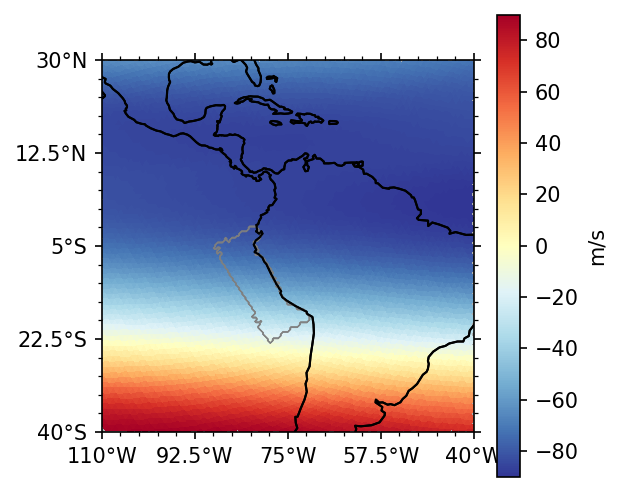

In [16]:
fig, ax = plt.subplots(figsize=(4,4),
                       subplot_kw={'projection': ccrs.PlateCarree()},
                       dpi=150,)

ax, ct = u_def_test.pyic.plot(
        ax=ax, cax=0,
        fpath_tgrid=fpath_tgrid["atm"], 
        fpath_ckdtree=fpath_ckdtree["atm"],
        title_right="",
        plot_method='tgrid',
        land_facecolor="none",
        lon_reg=[-110, -40],
        lat_reg=[-40, 30],
        cmap="RdYlBu_r",
        # use_pcol_or_contf=True, 
        # conts="auto",
)
fig.colorbar(ct[0], ax=ax, orientation='vertical', label='m/s', pad=0.05)

ax, ct = (mask_atm_plot["pc_all"] + 1).pyic.plot(
        ax=ax, cax=0,
        fpath_tgrid=fpath_tgrid['atm'],
        fpath_ckdtree=fpath_ckdtree['atm'],
        lon_reg=[-110, -40],
        lat_reg=[-40, 30],
        land_facecolor="none",
        use_pcol_or_contf=False,
        conts=1.0,
        contcolor='grey',
    )
for line in ct:
    line.set_linewidths(0.2)
    # line.set_linestyle('dashed')

In [36]:
# regional mean of u, v at each layer over time
# dim: (time, height)
u_def_reg = funcs_crop_region.regional_area_mean_atm(u_def, ds_tg_atm, mask_atm)
u_ck3_reg = funcs_crop_region.regional_area_mean_atm(u_ck3, ds_tg_atm, mask_atm)
v_def_reg = funcs_crop_region.regional_area_mean_atm(v_def, ds_tg_atm, mask_atm)
v_ck3_reg = funcs_crop_region.regional_area_mean_atm(v_ck3, ds_tg_atm, mask_atm)

In [38]:
# select month
u_def_reg_aso = u_def_reg.sel(time=u_def_reg.time.dt.month.isin(months_aso))
u_ck3_reg_aso = u_ck3_reg.sel(time=u_ck3_reg.time.dt.month.isin(months_aso))
u_def_reg_fma = u_def_reg.sel(time=u_def_reg.time.dt.month.isin(months_fma))
u_ck3_reg_fma = u_ck3_reg.sel(time=u_ck3_reg.time.dt.month.isin(months_fma))

v_def_reg_aso = v_def_reg.sel(time=v_def_reg.time.dt.month.isin(months_aso))
v_ck3_reg_aso = v_ck3_reg.sel(time=v_ck3_reg.time.dt.month.isin(months_aso))
v_def_reg_fma = v_def_reg.sel(time=v_def_reg.time.dt.month.isin(months_fma))
v_ck3_reg_fma = v_ck3_reg.sel(time=v_ck3_reg.time.dt.month.isin(months_fma))

In [40]:
# calculate the time mean for: (1) annual mean; (2) ASO mean; (3) FMA mean
u_def_reg_clim = u_def_reg.mean(dim="time").compute()
u_ck3_reg_clim = u_ck3_reg.mean(dim="time").compute()
u_def_reg_aso_clim = u_def_reg_aso.mean(dim="time").compute()
u_ck3_reg_aso_clim = u_ck3_reg_aso.mean(dim="time").compute()
u_def_reg_fma_clim = u_def_reg_fma.mean(dim="time").compute()
u_ck3_reg_fma_clim = u_ck3_reg_fma.mean(dim="time").compute()

v_def_reg_clim = v_def_reg.mean(dim="time").compute()
v_ck3_reg_clim = v_ck3_reg.mean(dim="time").compute()
v_def_reg_aso_clim = v_def_reg_aso.mean(dim="time").compute()
v_ck3_reg_aso_clim = v_ck3_reg_aso.mean(dim="time").compute()
v_def_reg_fma_clim = v_def_reg_fma.mean(dim="time").compute()
v_ck3_reg_fma_clim = v_ck3_reg_fma.mean(dim="time").compute()

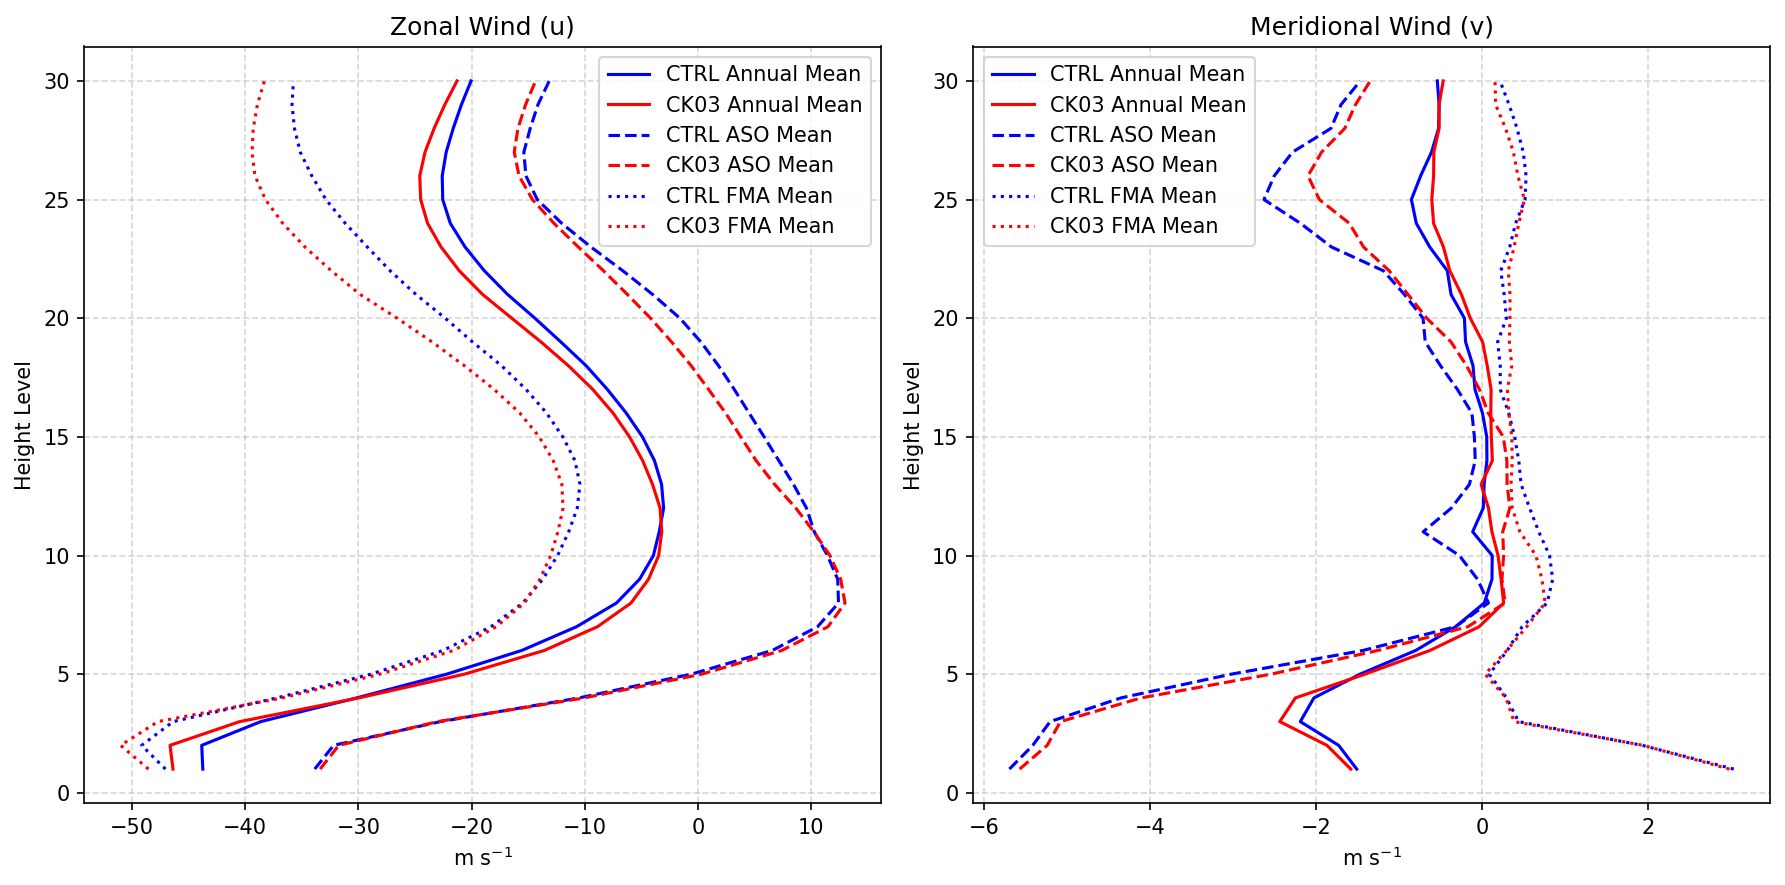

In [42]:
# plot the annual mean, ASO mean, FMA mean of u, v profiles, each subplot for the three means, x-axis is u or v, y-axis is height, two lines for CTRL and CK03
fig, axes = plt.subplots(1, 2, figsize=(12,6), dpi=150)
axes = axes.flatten()
fields = [
    ("Zonal Wind (u)", u_def_reg_clim, u_ck3_reg_clim, u_def_reg_aso_clim, u_ck3_reg_aso_clim, u_def_reg_fma_clim, u_ck3_reg_fma_clim),
    ("Meridional Wind (v)", v_def_reg_clim, v_ck3_reg_clim, v_def_reg_aso_clim, v_ck3_reg_aso_clim, v_def_reg_fma_clim, v_ck3_reg_fma_clim),
]   
for ax, (title, clim_def, clim_ck3, aso_clim_def, aso_clim_ck3, fma_clim_def, fma_clim_ck3) in zip(axes, fields):
    ax.plot(clim_def, clim_def.height, c="b", label="CTRL Annual Mean")
    ax.plot(clim_ck3, clim_ck3.height, c="r", label="CK03 Annual Mean")
    ax.plot(aso_clim_def, aso_clim_def.height, c="b", linestyle='dashed', label="CTRL ASO Mean")
    ax.plot(aso_clim_ck3, aso_clim_ck3.height, c="r", linestyle='dashed', label="CK03 ASO Mean")
    ax.plot(fma_clim_def, fma_clim_def.height, c="b", linestyle='dotted', label="CTRL FMA Mean")
    ax.plot(fma_clim_ck3, fma_clim_ck3.height, c="r", linestyle='dotted', label="CK03 FMA Mean")
    ax.set_xlabel("m s$^{-1}$")
    ax.set_ylabel("Height Level")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.5, linestyle='--')
fig.tight_layout()
save_path = "/home/m/m301254/project_surfwaves/figs/mux0003_b5b7/pc_all/clim_u_v_profile_pc-all.png"
plt.savefig(save_path, dpi=100)
plt.show()
